In [ ]:
file_path = "data_scaling_skewed_data.csv"

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [ ]:
df.shape

(100, 7)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            100 non-null    int64  
 1   Study_Hours           100 non-null    float64
 2   Age                   100 non-null    int64  
 3   Attendance            97 non-null     float64
 4   Family_Income         100 non-null    float64
 5   Internet_Usage_Hours  98 non-null     float64
 6   Exam_Score            100 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 5.6 KB


In [ ]:
df.describe()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,3.838400,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,2.453124,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,0.430000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,2.180000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,3.395000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,4.810000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,14.600000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()


Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [ ]:
df


,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,4.79,4.79,25,68.22,26401.83,5.13,68.46
1,2.99,2.99,25,72.62,29899.43,10.14,58.53
2,2.76,2.76,24,87.15,84956.82,6.63,50.72
3,2.76,2.76,20,87.14,15797.16,0.99,72.44
4,9.30,9.30,18,87.15,44019.48,2.10,60.92
...,...,...,...,...,...,...,...
95,1.81,1.81,25,88.30,81963.94,1.02,43.47
96,10.84,10.84,18,73.71,6406.16,4.37,72.83
97,4.71,4.71,18,76.40,15686.61,7.90,79.25
98,1.40,1.40,20,89.47,27030.45,2.51,52.26


In [ ]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score'],
      dtype='str')

In [ ]:
numerical_col = ['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score']
corr_matrix = df[numerical_col].corr()
corr_matrix

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
Student_ID,1.000000,1.000000,-0.035483,-0.088588,0.057223,-0.020783,0.069318
Study_Hours,1.000000,1.000000,-0.035483,-0.088588,0.057223,-0.020783,0.069318
Age,-0.035483,-0.035483,1.000000,0.025923,0.054697,0.025997,0.012881
Attendance,-0.088588,-0.088588,0.025923,1.000000,-0.005532,-0.069543,0.019875
Family_Income,0.057223,0.057223,0.054697,-0.005532,1.000000,-0.005486,-0.027481
Internet_Usage_Hours,-0.020783,-0.020783,0.025997,-0.069543,-0.005486,1.000000,0.109160
Exam_Score,0.069318,0.069318,0.012881,0.019875,-0.027481,0.109160,1.000000


<Axes: >

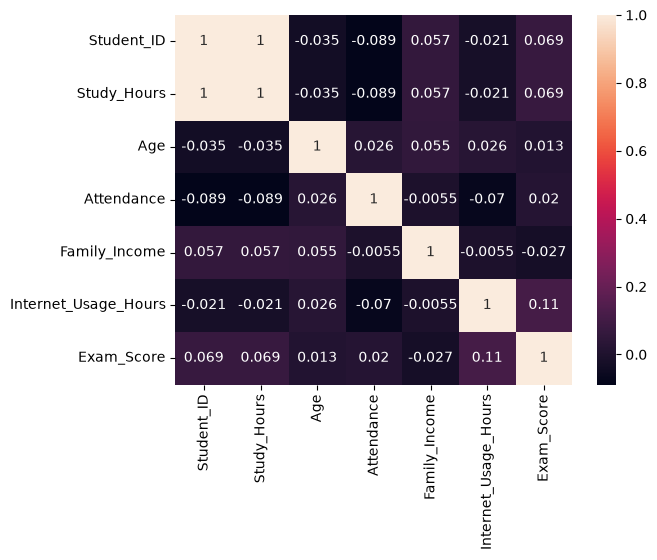

In [ ]:

import seaborn as sns
sns.heatmap(corr_matrix,annot = True)

In [ ]:
#df["Attendance"].median()

In [ ]:
#df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())
#df

In [ ]:
#df["Internet_Usage_Hours"].median()

In [ ]:

'''df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(
    df["Internet_Usage_Hours"].median()
)
df'''

'df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(\n    df["Internet_Usage_Hours"].median()\n)\ndf'

In [ ]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [ ]:
mean_attendance = df.groupby("Age")["Attendance"].transform("mean")

In [ ]:
mask_Atten = df["Attendance"].isna()
df.loc[mask_Atten, "Attendance"] = mean_attendance[mask_Atten]

In [ ]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [ ]:
mean_internet = df.groupby("Age")["Internet_Usage_Hours"].transform("mean")
mask_Internet = df["Internet_Usage_Hours"].isna()
df.loc[mask_Internet, "Internet_Usage_Hours"] = mean_internet[mask_Internet]

In [ ]:
df["Internet_Usage_Hours"].isna().sum()

np.int64(0)

In [ ]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

In [ ]:
df[numerical_col].skew()

Student_ID              1.466644
Study_Hours             1.466644
Age                    -0.104205
Attendance             -0.280260
Family_Income           2.242351
Internet_Usage_Hours    1.469181
Exam_Score              0.038566
dtype: float64

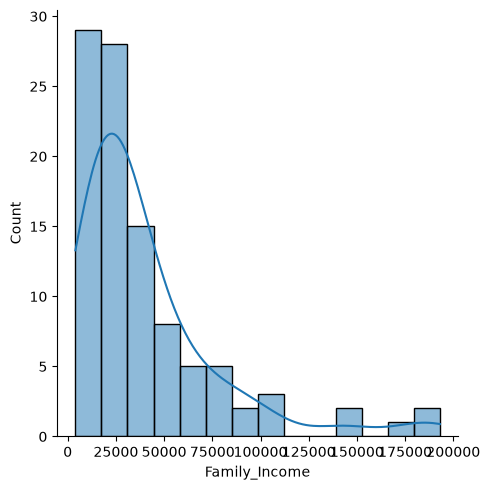

In [ ]:
import seaborn as sns
sns.displot(df["Family_Income"], kde=True)

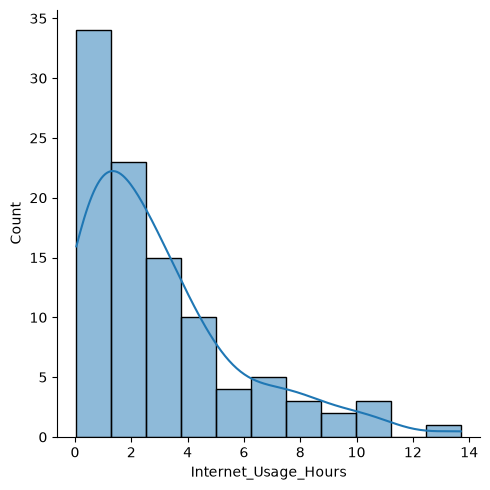

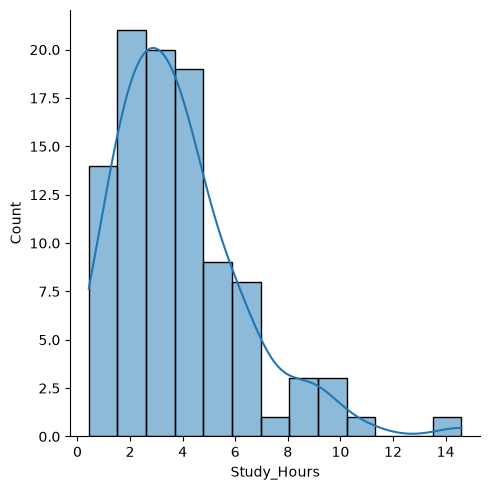

In [ ]:
sns.displot(df["Internet_Usage_Hours"], kde=True)
sns.displot(df["Study_Hours"], kde=True)

In [ ]:
df["Study_Efficiency"] = df["Study_Hours"] / df["Internet_Usage_Hours"]

In [ ]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,Study_Efficiency
0,4.79,4.79,25,68.22,26401.83,5.13,68.46,0.933723
1,2.99,2.99,25,72.62,29899.43,10.14,58.53,0.294872
2,2.76,2.76,24,87.15,84956.82,6.63,50.72,0.416290
3,2.76,2.76,20,87.14,15797.16,0.99,72.44,2.787879
4,9.30,9.30,18,87.15,44019.48,2.10,60.92,4.428571


In [ ]:
numerical_col = ['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score']
corr_matrix = df[numerical_col].corr()
corr_matrix

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
Student_ID,1.000000,1.000000,-0.035483,-0.085198,0.057223,-0.020982,0.069318
Study_Hours,1.000000,1.000000,-0.035483,-0.085198,0.057223,-0.020982,0.069318
Age,-0.035483,-0.035483,1.000000,0.025235,0.054697,0.028886,0.012881
Attendance,-0.085198,-0.085198,0.025235,1.000000,-0.006731,-0.064614,0.014454
Family_Income,0.057223,0.057223,0.054697,-0.006731,1.000000,-0.007532,-0.027481
Internet_Usage_Hours,-0.020982,-0.020982,0.028886,-0.064614,-0.007532,1.000000,0.111660
Exam_Score,0.069318,0.069318,0.012881,0.014454,-0.027481,0.111660,1.000000


<Axes: >

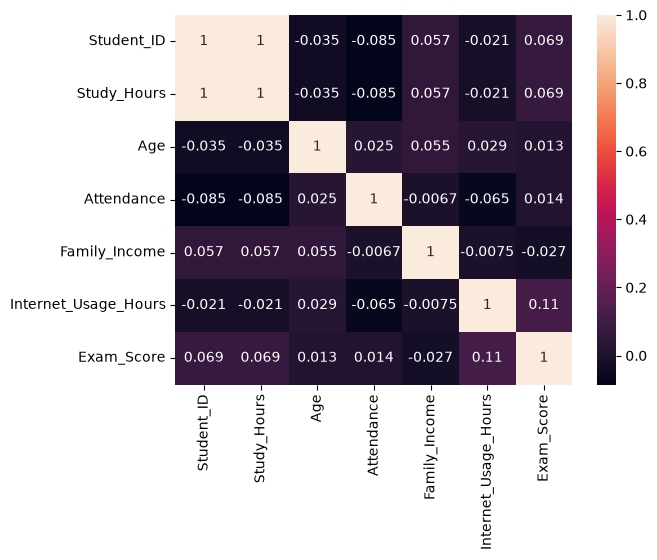

In [ ]:
sns.heatmap(corr_matrix, annot=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = [
    "Study_Hours",
    "Age",
    "Attendance",
    "Family_Income",
    "Internet_Usage_Hours",
    "Exam_Score"
]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [ ]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score,Study_Efficiency
0,4.79,0.307692,1.000000,0.369570,0.118586,0.372161,0.515396,0.933723
1,2.99,0.180663,1.000000,0.456854,0.137082,0.739194,0.333394,0.294872
2,2.76,0.164432,0.857143,0.745090,0.428245,0.482051,0.190249,0.416290
3,2.76,0.164432,0.285714,0.744892,0.062505,0.068864,0.588343,2.787879
4,9.30,0.625970,0.000000,0.745090,0.211754,0.150183,0.377199,4.428571


In [ ]:
df[cols_to_scale].describe()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.240536,0.524286,0.639739,0.192700,0.215071,0.504841
std,0.173121,0.342216,0.194695,0.200649,0.206379,0.211772
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.123500,0.285714,0.512944,0.063337,0.054579,0.354380
50%,0.209245,0.571429,0.656219,0.124181,0.158242,0.500367
75%,0.309104,0.857143,0.772615,0.232509,0.285714,0.660695
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.skew()

Student_ID              1.466644
Study_Hours             1.466644
Age                    -0.104205
Attendance             -0.280260
Family_Income           2.242351
Internet_Usage_Hours    1.469181
Exam_Score              0.038566
Study_Efficiency        7.012865
dtype: float64

In [ ]:
cols = df.columns.tolist()
cols

['Student_ID',
 'Study_Hours',
 'Age',
 'Attendance',
 'Family_Income',
 'Internet_Usage_Hours',
 'Exam_Score',
 'Study_Efficiency']

In [ ]:
import numpy as np
for col in cols:
    print(f"=={col}skew value==")
    print(skew (df[col]))

==Student_IDskew value==


NameError: name 'skew' is not defined

<Figure size 500x600 with 0 Axes>

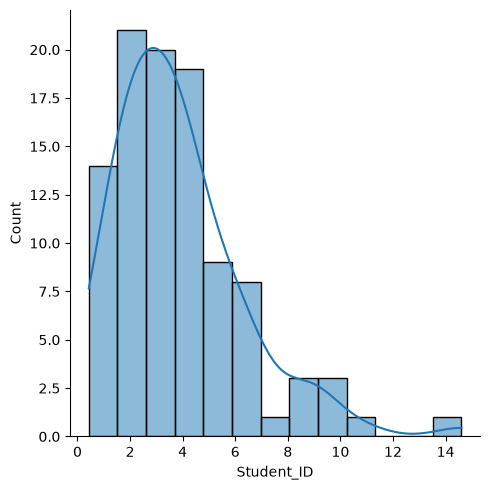

<Figure size 500x600 with 0 Axes>

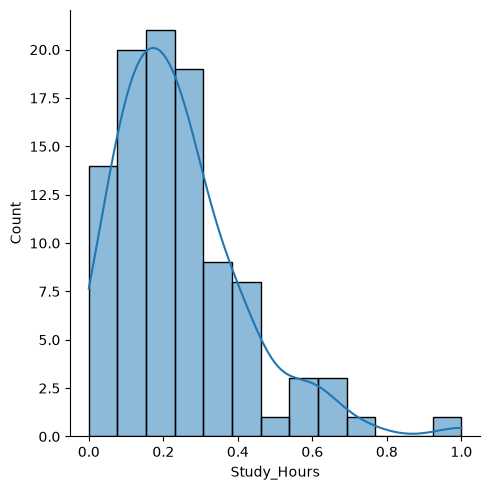

<Figure size 500x600 with 0 Axes>

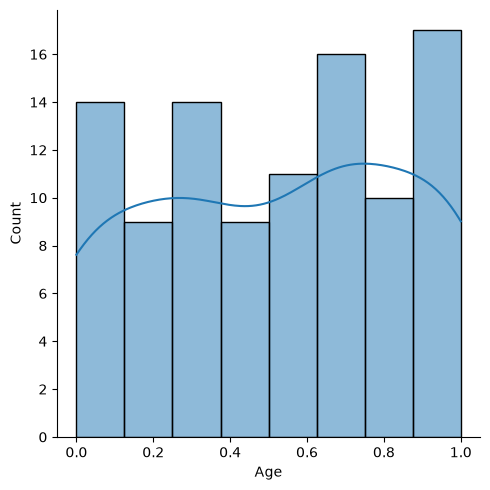

<Figure size 500x600 with 0 Axes>

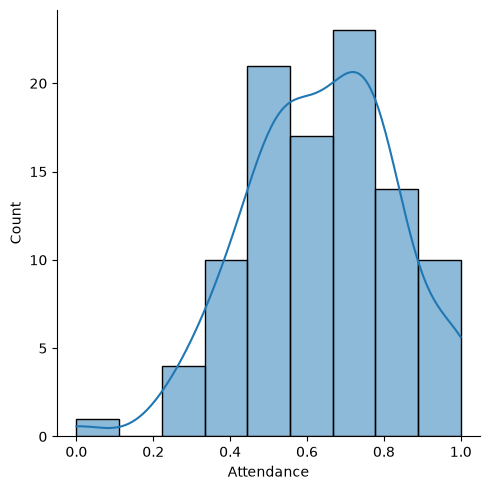

<Figure size 500x600 with 0 Axes>

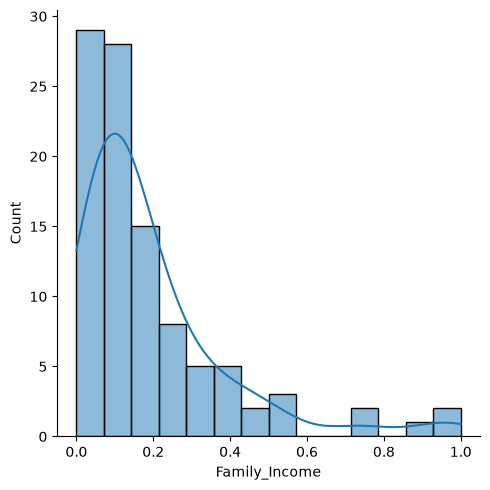

<Figure size 500x600 with 0 Axes>

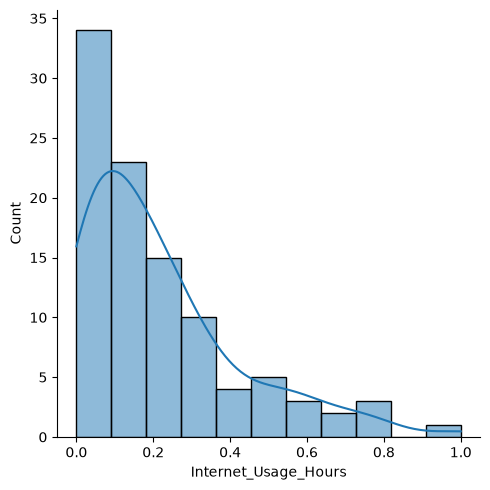

<Figure size 500x600 with 0 Axes>

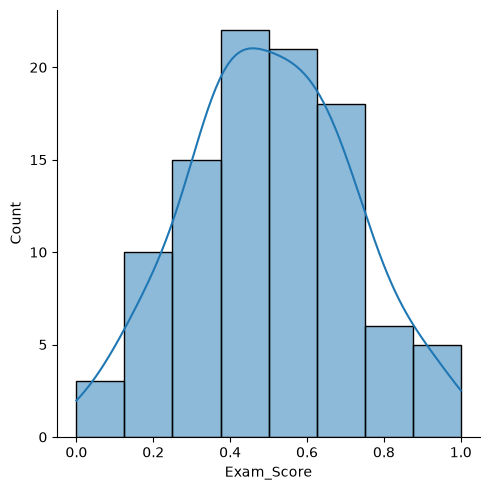

<Figure size 500x600 with 0 Axes>

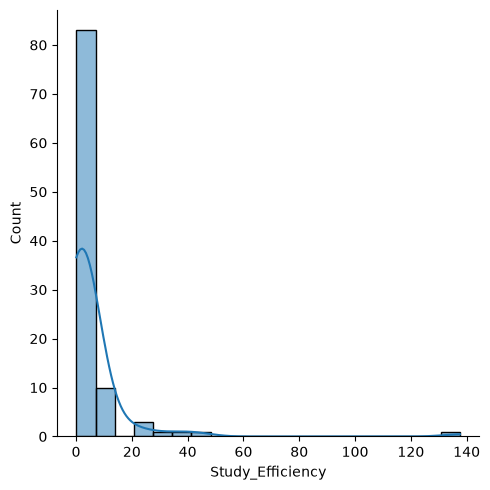

In [ ]:
from scipy.stats import skew 
from matplotlib.figure import SubFigure
import matplotlib.pyplot as plt
import seaborn as sns
for col in cols:
    plt.figure(figsize=(5,6))
    sns.displot(df[col],kde=True)
    plt.show()

====Log Transformation====
--after log tranform of Student_ID--
-0.5680524612827917


<Figure size 600x400 with 0 Axes>

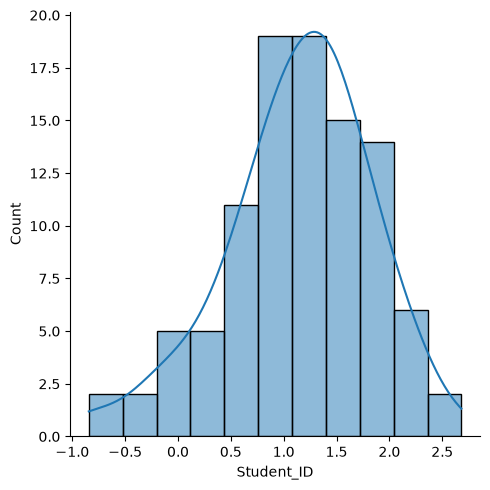

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Study_Hours--
nan


<Figure size 600x400 with 0 Axes>

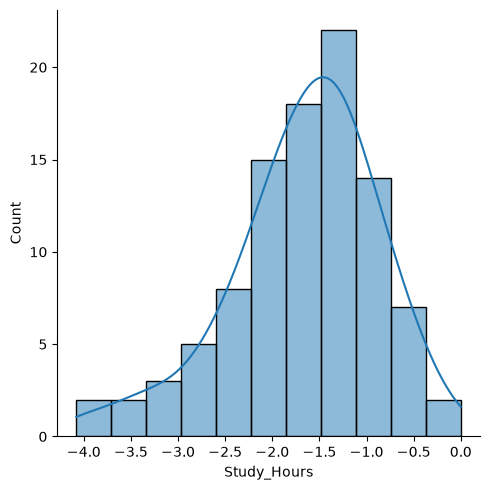

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Age--
nan


<Figure size 600x400 with 0 Axes>

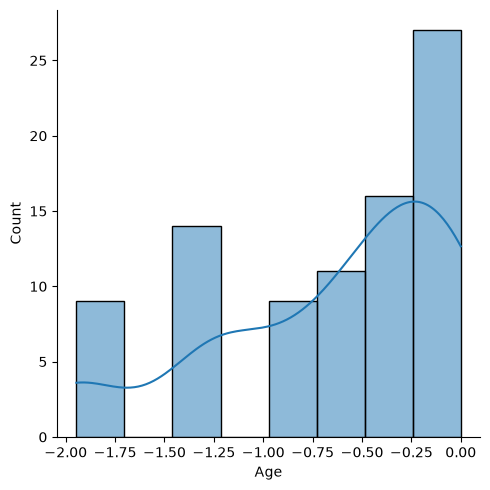

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Attendance--
nan


<Figure size 600x400 with 0 Axes>

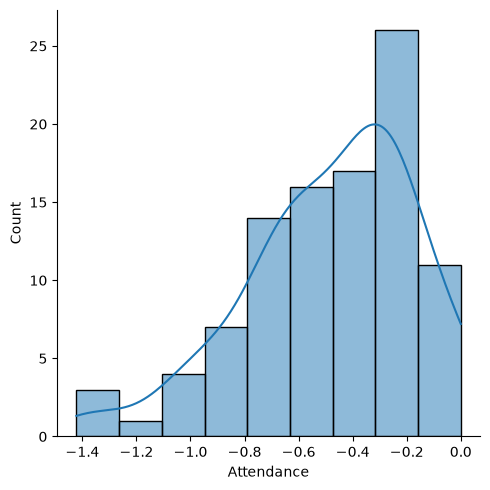

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Family_Income--
nan


<Figure size 600x400 with 0 Axes>

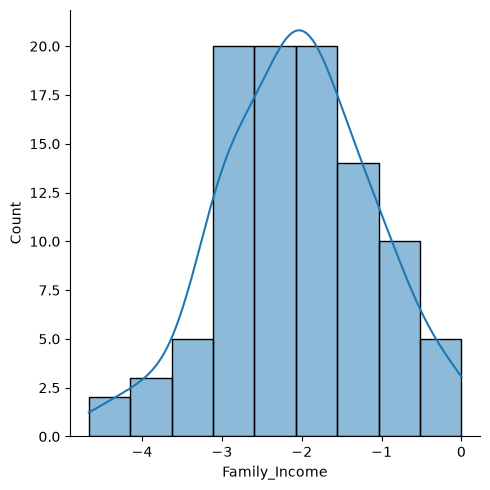

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Internet_Usage_Hours--
nan


<Figure size 600x400 with 0 Axes>

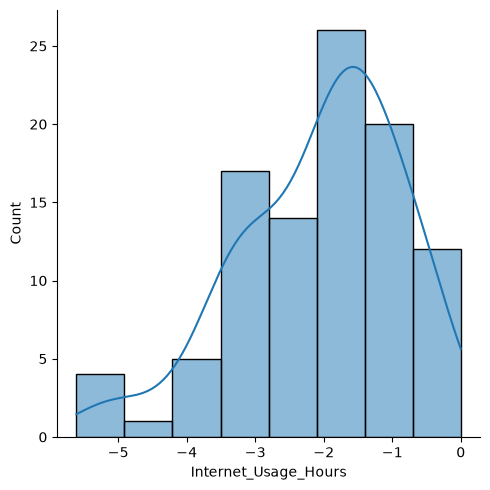

c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\rband\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_stats_py.py:1172: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


--after log tranform of Exam_Score--
nan


<Figure size 600x400 with 0 Axes>

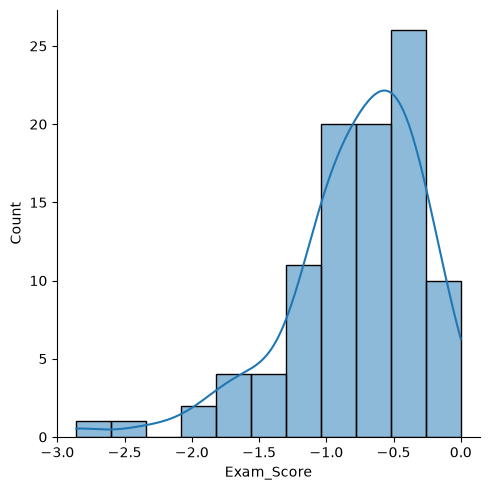

--after log tranform of Study_Efficiency--
0.4706978275058261


<Figure size 600x400 with 0 Axes>

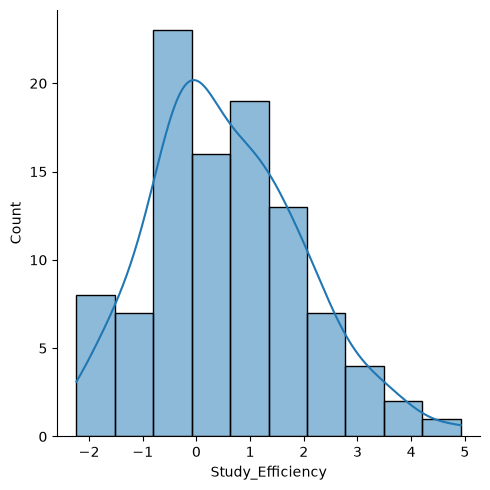

In [ ]:
import numpy as np
print("====Log Transformation====")
for col in cols:
    log_data = np.log(df[col])
    print(f"--after log tranform of {col}--")
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show()


====Log Transformation====
--after log tranform of Student_ID--
-0.00969388869999056


<Figure size 600x400 with 0 Axes>

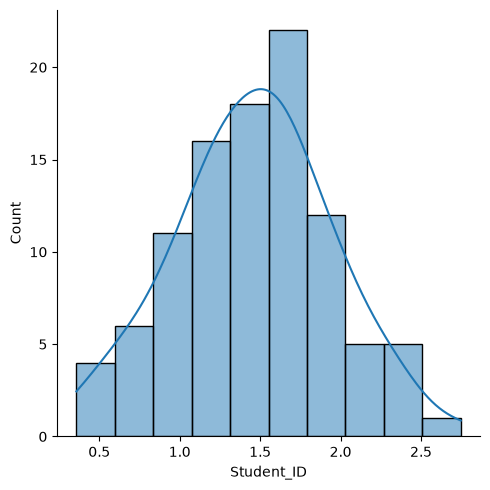

--after log tranform of Study_Hours--
0.956442194982663


<Figure size 600x400 with 0 Axes>

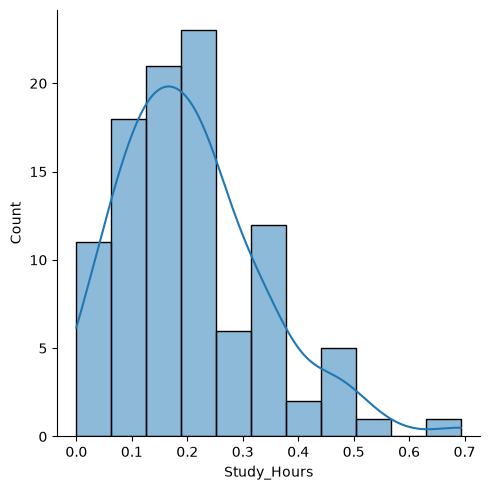

--after log tranform of Age--
-0.35281890285564693


<Figure size 600x400 with 0 Axes>

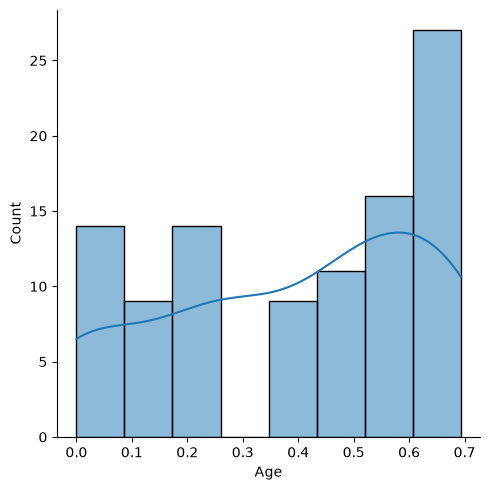

--after log tranform of Attendance--
-0.7211622630889774


<Figure size 600x400 with 0 Axes>

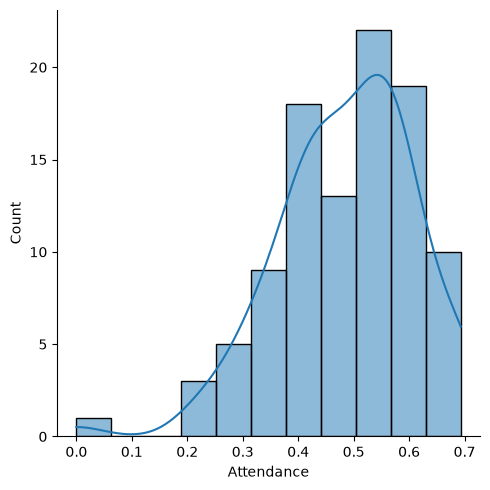

--after log tranform of Family_Income--
1.7471077242022666


<Figure size 600x400 with 0 Axes>

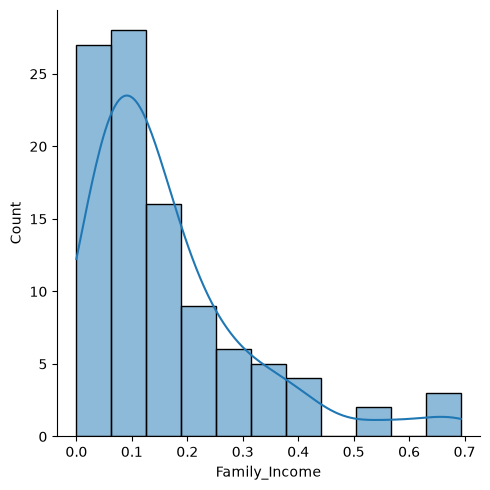

--after log tranform of Internet_Usage_Hours--
1.0881651582580496


<Figure size 600x400 with 0 Axes>

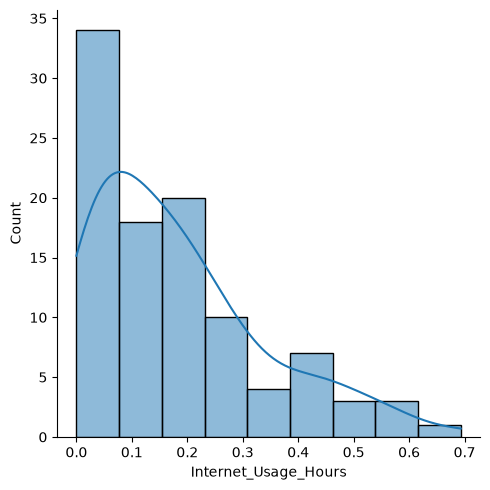

--after log tranform of Exam_Score--
-0.31923046815989137


<Figure size 600x400 with 0 Axes>

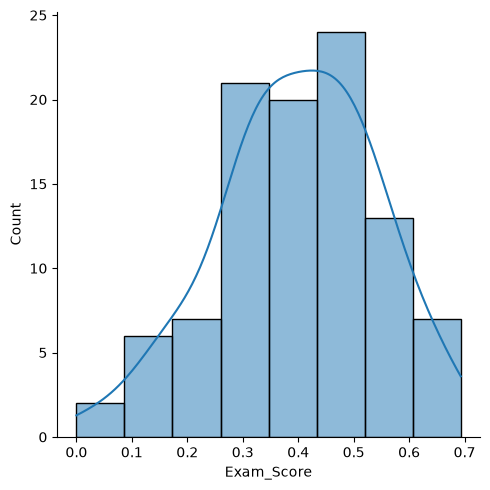

--after log tranform of Study_Efficiency--
1.3868930090836966


<Figure size 600x400 with 0 Axes>

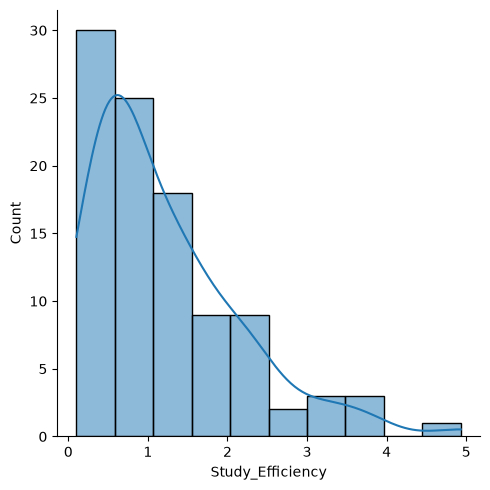

In [ ]:
import numpy as np
print("====Log Transformation====")
for col in cols:
    log_data = np.log1p(df[col])
    print(f"--after log tranform of {col}--")
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show()


====Log Transformation====
--after log tranform of Student_ID--
0.45307781244976447


<Figure size 600x400 with 0 Axes>

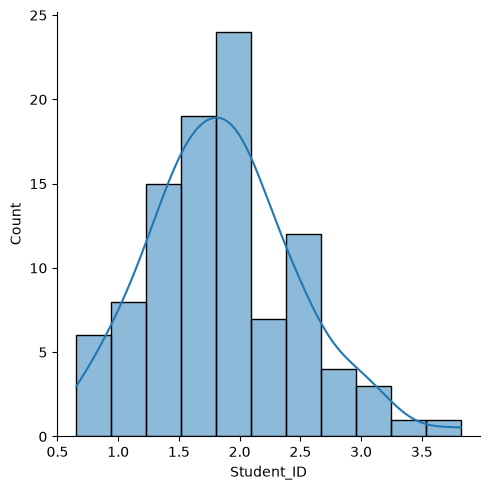

--after log tranform of Study_Hours--
0.12772154316105258


<Figure size 600x400 with 0 Axes>

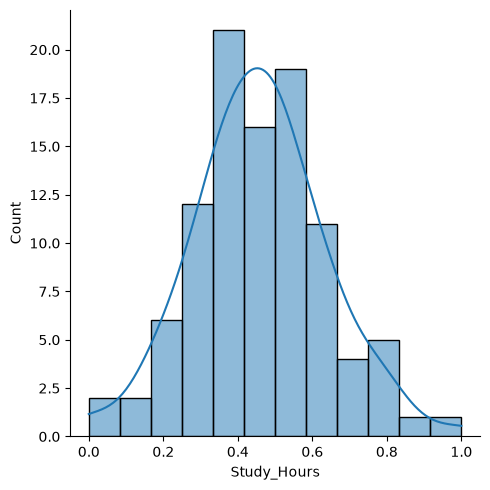

--after log tranform of Age--
-0.8829331711722241


<Figure size 600x400 with 0 Axes>

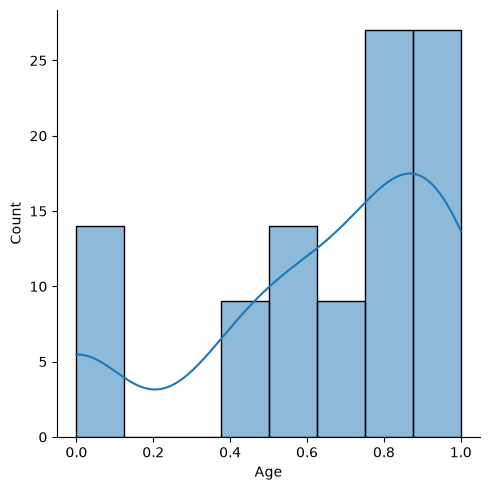

--after log tranform of Attendance--
-1.802907046153179


<Figure size 600x400 with 0 Axes>

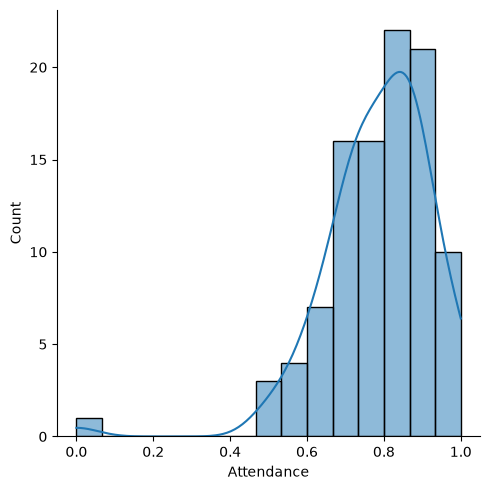

--after log tranform of Family_Income--
1.0408750337963741


<Figure size 600x400 with 0 Axes>

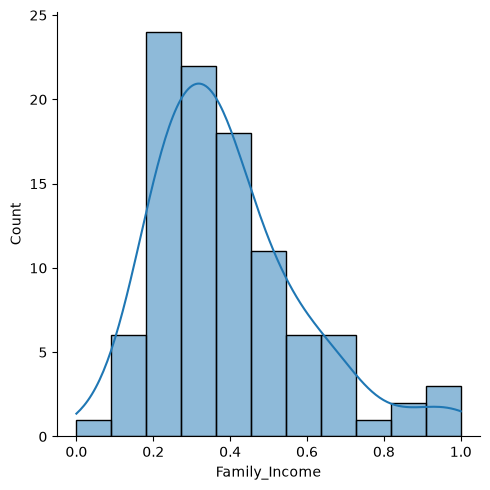

--after log tranform of Internet_Usage_Hours--
0.47059059638848594


<Figure size 600x400 with 0 Axes>

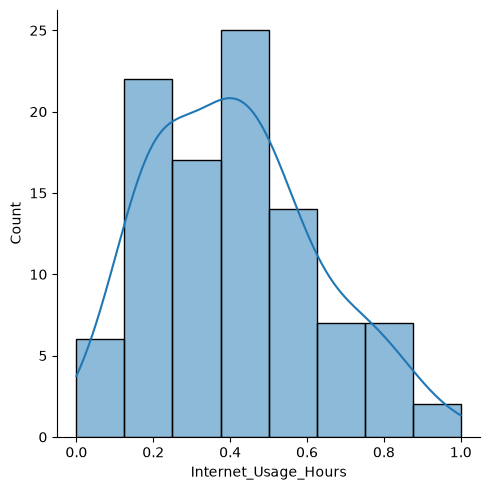

--after log tranform of Exam_Score--
-0.9542319153335895


<Figure size 600x400 with 0 Axes>

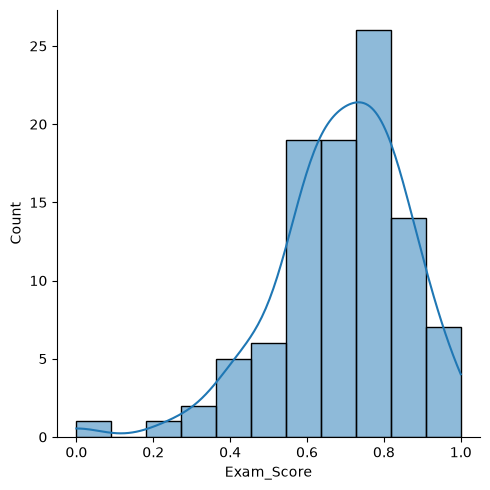

--after log tranform of Study_Efficiency--
3.2581066305816124


<Figure size 600x400 with 0 Axes>

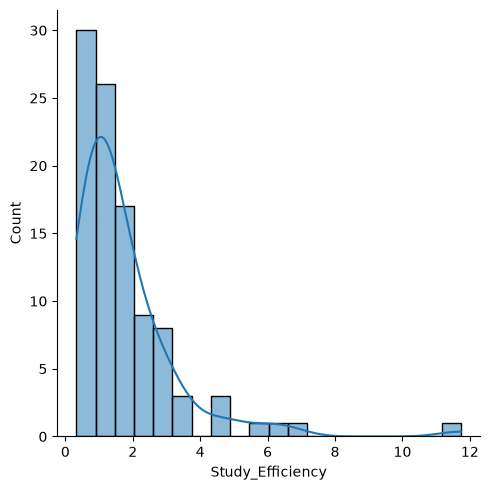

In [ ]:
import numpy as np
print("====Log Transformation====")
for col in cols:
    log_data = np.sqrt(df[col])
    print(f"--after log tranform of {col}--")
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show()


====Log Transformation====
--after log tranform of 0.2720661415245264--
-0.0010955199947447604


<Figure size 600x400 with 0 Axes>

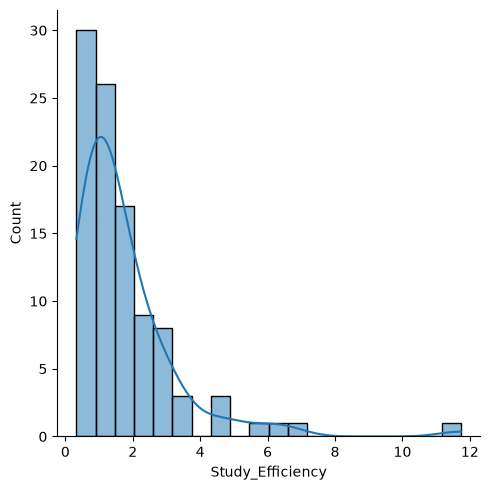

ValueError: Data must be positive.

In [ ]:

from scipy.stats import boxcox,yeojohnson
import numpy as np
print("====Log Transformation====")
for col in cols:
    data,l = boxcox(df[col])
    print(f"--after log tranform of {l}--")
    print(skew(data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show()


====Log Transformation====
--after log tranform of 0.007217082807872859--
-0.00021075313062609378


<Figure size 600x400 with 0 Axes>

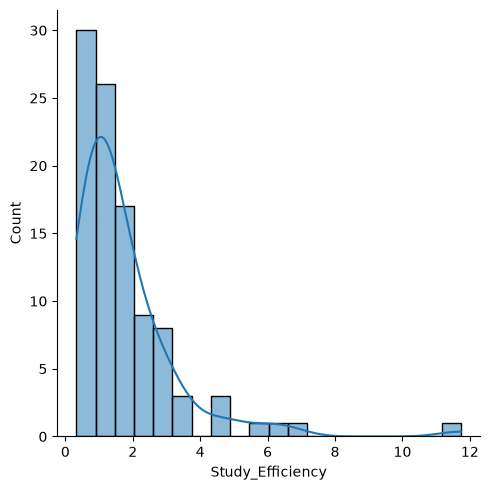

--after log tranform of -2.5579955889964894--
0.05558264152120778


<Figure size 600x400 with 0 Axes>

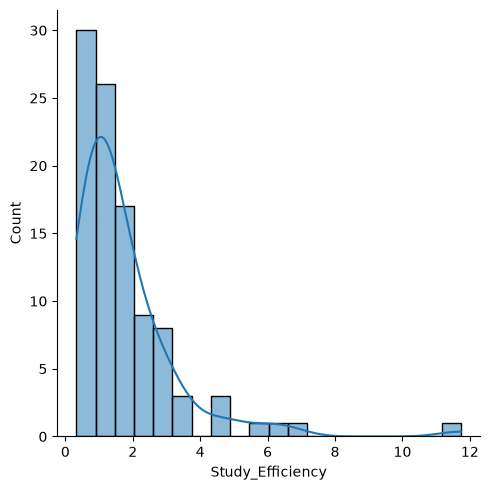

--after log tranform of 1.001423057367657--
-0.10228676761341086


<Figure size 600x400 with 0 Axes>

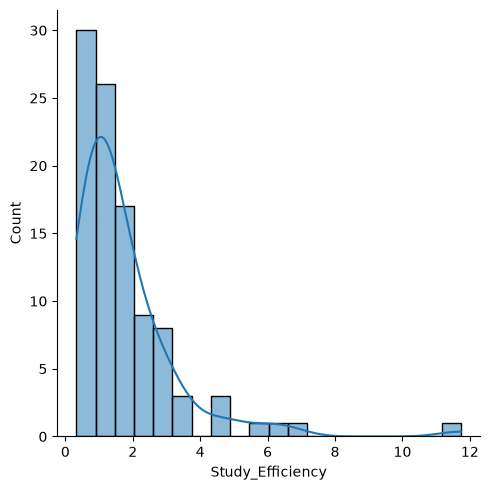

--after log tranform of 1.7375430028613261--
-0.009094212785810355


<Figure size 600x400 with 0 Axes>

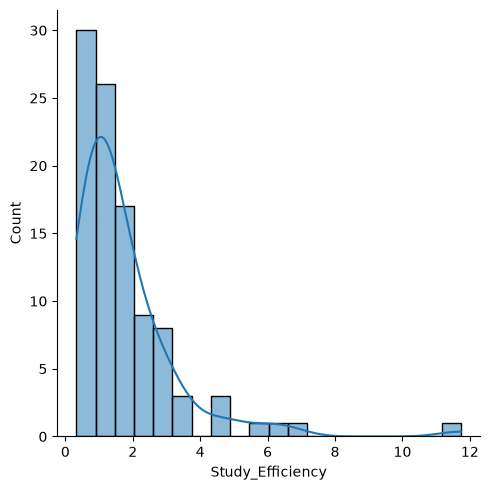

--after log tranform of -4.941028034665732--
0.2760080550874569


<Figure size 600x400 with 0 Axes>

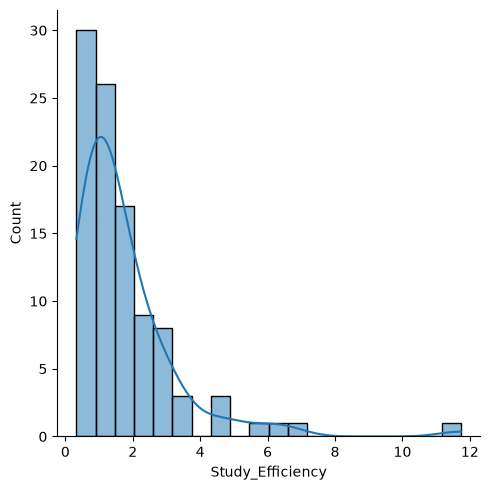

--after log tranform of -3.4304488483146316--
0.20683971099634696


<Figure size 600x400 with 0 Axes>

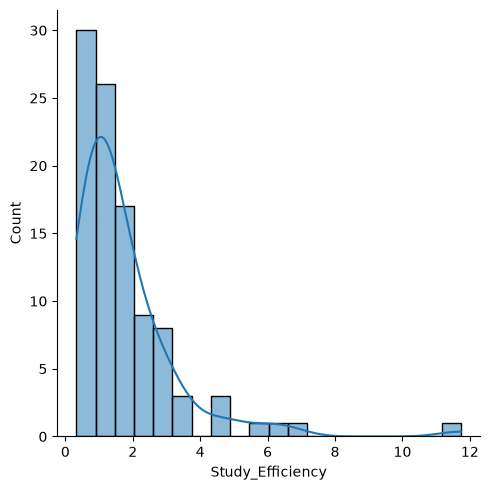

--after log tranform of 0.8484861329024905--
-0.014711917528120561


<Figure size 600x400 with 0 Axes>

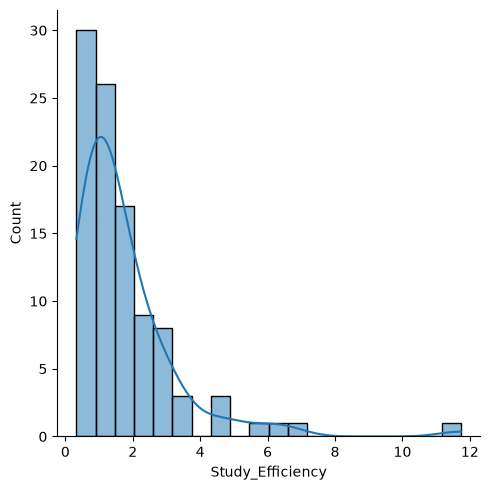

--after log tranform of -0.6260490412951586--
0.22368984709916284


<Figure size 600x400 with 0 Axes>

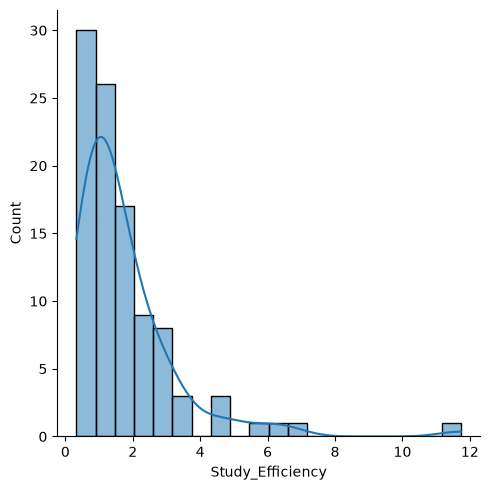

In [ ]:

from scipy.stats import boxcox,yeojohnson
import numpy as np
print("====Log Transformation====")
for col in cols:
    data,l = yeojohnson(df[col])
    print(f"--after log tranform of {l}--")
    print(skew(data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show()
